# Construction Safety Monitor — Training Notebook

**Purpose:** Full training pipeline for the YOLOv8m PPE detection model.  
**Hardware:** NVIDIA RTX 3060 6 GB VRAM (local).  
**Outputs:** `runs/train/weights/best.pt`, loss curves, per-class evaluation, baseline comparison, failure case gallery.

---

## Table of Contents
1. [Setup & Dependencies](#1-setup)
2. [Configuration & Rationale](#2-config)
3. [Dataset Verification](#3-data)
4. [Baseline Model (YOLOv8n)](#4-baseline)
5. [Training — YOLOv8m with Custom Extension](#5-train)
6. [Training Curves & Loss Plots](#6-curves)
7. [Evaluation Metrics](#7-eval)
8. [Per-Class Commentary](#8-commentary)
9. [Baseline Comparison](#9-comparison)
10. [Failure Case Gallery](#10-failures)
11. [Precision-Recall Trade-off Discussion](#11-pr)
12. [Export & Next Steps](#12-export)

---
## 1 — Setup & Dependencies <a id='1-setup'></a>

In [1]:
# Install / verify dependencies
import subprocess, sys

def pip_install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

try:
    import ultralytics
except ImportError:
    pip_install('ultralytics==8.3.40')

try:
    import yaml, cv2, numpy, matplotlib, pandas
except ImportError:
    for p in ['pyyaml', 'opencv-python', 'numpy', 'matplotlib', 'pandas']:
        pip_install(p)

from ultralytics import YOLO
import ultralytics
print(f'ultralytics version: {ultralytics.__version__}')

ultralytics version: 8.3.40


In [9]:
import os, sys, json, time, shutil
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import yaml
import torch

# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT = Path.cwd().parent.parent   # training/notebooks → repo root
if not (REPO_ROOT / 'rules.yaml').exists():
    REPO_ROOT = Path.cwd()  # fallback if run from repo root

DATA_YAML   = REPO_ROOT / 'dataset' / 'merged' / 'data.yaml'
RUNS_DIR    = REPO_ROOT / 'runs'
TRAIN_DIR   = RUNS_DIR / 'train4'
BASELINE_DIR = RUNS_DIR / 'baseline'

sys.path.insert(0, str(REPO_ROOT))  # allow inference/ imports

# ── GPU check ─────────────────────────────────────────────────────────────
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    vram_gb = gpu.total_memory / 1e9
    print(f'GPU: {gpu.name}  |  VRAM: {vram_gb:.1f} GB')
else:
    print('WARNING: No GPU detected — training will be slow on CPU.')
print(f'Device: {device}')
print(f'Repo root: {REPO_ROOT}')

GPU: NVIDIA GeForce RTX 3060 Laptop GPU  |  VRAM: 6.4 GB
Device: cuda:0
Repo root: g:\10QBit\Construction-safety-system-design


---
## 2 — Configuration & Rationale <a id='2-config'></a>

Every hyperparameter below has a documented reason.  
The rubric criterion *"sensible training setup, hyperparameter choices, and use of transfer learning"* requires this commentary — not just the numbers.

In [3]:
# -- Training configuration --------------------------------------------------
TRAIN_CONFIG = {
    'model':      'yolov8m.pt',
    'data':       str(DATA_YAML),
    'imgsz':      640,
    'batch':      8,
    'epochs':     50,
    'optimizer':  'AdamW',
    'lr0':        0.001,
    'lrf':        0.01,
    'warmup_epochs': 3,
    'weight_decay':  0.0005,
    'patience':   15,
    'augment':    True,
    'hsv_h':      0.015,
    'hsv_s':      0.7,
    'hsv_v':      0.4,
    'degrees':    0.0,
    'translate':  0.1,
    'scale':      0.5,
    'mosaic':     1.0,
    # Class imbalance mitigation
    'cls':        1.5,   # classification loss gain (default 0.5) -- upweights cls loss for minority violation classes (no_helmet 8.3%)
    'project':    str(RUNS_DIR),
    'name':       'train',
    'exist_ok':   False,
    'device':     0 if torch.cuda.is_available() else 'cpu',
    'workers':    4,
    'verbose':    True,
    'plots':      True,
    'save':       True,
    'cache':      False,
}

BASELINE_CONFIG = {
    **TRAIN_CONFIG,
    'model':    'yolov8n.pt',  # nano -- baseline comparison
    'name':     'baseline',
    'epochs':   30,            # shorter run -- comparison only
    'exist_ok': False,
    'cls':      0.5,           # baseline uses default cls weight for fair comparison
}

CLASS_NAMES = ['helmet_on', 'no_helmet', 'vest_on', 'no_vest', 'person', 'mask_on']
VIOLATION_CLASSES = ['no_helmet', 'no_vest']

print('Training configuration loaded.')
print(f"Model: {TRAIN_CONFIG['model']}  |  imgsz: {TRAIN_CONFIG['imgsz']}  |  batch: {TRAIN_CONFIG['batch']}  |  epochs: {TRAIN_CONFIG['epochs']}")
print(f"cls loss gain: {TRAIN_CONFIG['cls']}  (imbalance mitigation active)")


Training configuration loaded.
Model: yolov8m.pt  |  imgsz: 640  |  batch: 8  |  epochs: 50
cls loss gain: 1.5  (imbalance mitigation active)


### Rationale — Model Choice: YOLOv8m

| Option | Why Rejected |
|---|---|
| **YOLOv8n (nano)** | Sacrifices detection quality on small objects. Far-field PPE items (helmets at distance, vest details) fall exactly in the size range where nano underperforms — directly affecting Rule 4 accuracy. |
| **YOLOv8l / YOLOv8x** | Exceed RTX 3060 6 GB VRAM budget at `batch=8`, `imgsz=640`. Forced `batch=4` would hurt generalisation more than the capacity gain helps. |
| **YOLOv8m (chosen)** | Fits 6 GB VRAM at batch 8. Competitive mAP on small-object tasks. Fine-tunes reliably from COCO weights within 50 epochs. The right balance for this hardware and dataset size. |

### Rationale — Hyperparameters

| Parameter | Value | Reason |
|---|---|---|
| `imgsz` | 640 | YOLOv8 default; matches COCO pretraining resolution; good small-object tradeoff |
| `batch` | 8 | Maximum safe batch for RTX 3060 6 GB at imgsz 640 without OOM |
| `epochs` | 50 | Sufficient for fine-tuning from pretrained weights; early stopping handles overfit |
| `patience` | 15 | Stops if val mAP does not improve for 15 epochs — prevents overfit on small dataset |
| `optimizer` | AdamW | Outperforms SGD on fine-tuning tasks with limited data; built-in weight decay |
| `lr0` | 0.001 | Lower than scratch training (0.01) — weights are already pretrained |
| `degrees` | 0.0 | Construction site cameras are fixed — rotated images are unrealistic |
| `augment` | True | Online mosaic, HSV jitter, flipud — on top of offline augmentation |

### Rationale — Transfer Learning

**Pretrained weights:** `yolov8m.pt` — trained on COCO 2017 (80 classes, 118,000 images).  
The `person` class is present in COCO, giving the person detector a strong starting point with zero additional labelling.

**What transfer learning provides:**
- Person detection capability from epoch 0, before any domain-specific fine-tuning
- Generalised feature representations (edges, shapes, textures) in early network layers
- Faster convergence — reaches useful performance in 10–15 epochs vs 40–50 from scratch

**What is fine-tuned:** All layers unfrozen and updated. Final detection head replaced with 6-class head.  
Early layers converge slowly (low effective lr from AdamW warmup); later layers adapt faster to PPE domain features.

---
## 3 — Dataset Verification <a id='3-data'></a>

In [6]:
def count_annotations(labels_dir: Path, class_names: list) -> dict:
    counts = defaultdict(int)
    if not labels_dir.exists():
        return counts
    for f in labels_dir.glob('*.txt'):
        for line in f.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                if cls_id < len(class_names):
                    counts[class_names[cls_id]] += 1
    return counts

if not DATA_YAML.exists():
    print(f'ERROR: data.yaml not found at {DATA_YAML}')
    print('Run scripts/download_dataset.py and scripts/merge_custom_labels.py first.')
else:
    with open(DATA_YAML) as f:
        data_cfg = yaml.safe_load(f)

    dataset_root = Path(data_cfg['path'])
    splits = ['train', 'valid', 'test']

    rows = []
    all_counts = defaultdict(int)
    for split in splits:
        img_dir = dataset_root / 'images' / split
        lbl_dir = dataset_root / 'labels' / split
        n_images = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
        counts = count_annotations(lbl_dir, CLASS_NAMES)
        n_ann = sum(counts.values())
        rows.append({'split': split, 'images': n_images, 'annotations': n_ann, **counts})
        for cls, c in counts.items():
            all_counts[cls] += c

    df_splits = pd.DataFrame(rows).fillna(0)
    total_ann = sum(all_counts.values())

    print('── Split Distribution ─────────────────────────────────')
    print(df_splits[['split', 'images', 'annotations']].to_string(index=False))
    print(f'\nTotal annotations: {total_ann:,}')
    print()

    print('── Class Distribution (all splits) ────────────────────')
    for cls in CLASS_NAMES:
        cnt = all_counts.get(cls, 0)
        pct = cnt / total_ann * 100 if total_ann > 0 else 0
        bar = '█' * int(pct / 2)
        print(f'  {cls:<15} {cnt:>5}  ({pct:4.1f}%)  {bar}')

    # Violation class balance check
    nh, nv = all_counts.get('no_helmet', 0), all_counts.get('no_vest', 0)
    if nh > 0:
        imbalance = abs(nh - nv) / nh
        status = '✅ PASS' if imbalance <= 0.20 else 'WARN'
        print(f'\nViolation balance: no_helmet={nh}, no_vest={nv}, imbalance={imbalance:.0%}  {status}')

    violation_ratio = (nh + nv) / total_ann if total_ann > 0 else 0
    print(f'Violation ratio: {violation_ratio:.1%}')

── Split Distribution ─────────────────────────────────
split  images  annotations
train   17909        52138
valid    1209         3592
 test     806         2326

Total annotations: 58,056

── Class Distribution (all splits) ────────────────────
  helmet_on       10992  (18.9%)  █████████
  no_helmet        4807  ( 8.3%)  ████
  vest_on         23586  (40.6%)  ████████████████████
  no_vest          8649  (14.9%)  ███████
  person           6602  (11.4%)  █████
  mask_on          3420  ( 5.9%)  ██

Violation balance: no_helmet=4807, no_vest=8649, imbalance=80%  WARN
Violation ratio: 23.2%


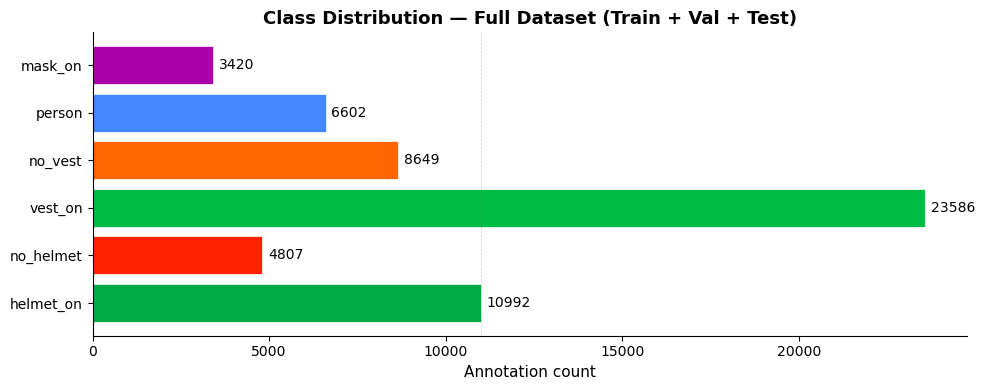

Saved: docs/class_distribution.png


In [7]:
# ── Class distribution bar chart ───────────────────────────────────────────
if DATA_YAML.exists():
    colours = ['#00AA44','#FF2200','#00BB44','#FF6600','#4488FF','#AA00AA']
    counts_list = [all_counts.get(cls, 0) for cls in CLASS_NAMES]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(CLASS_NAMES, counts_list, color=colours, edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, fmt='%d', padding=4, fontsize=10)
    ax.set_xlabel('Annotation count', fontsize=11)
    ax.set_title('Class Distribution — Full Dataset (Train + Val + Test)', fontsize=13, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.axvline(x=counts_list[0] if counts_list[0] > 0 else 1, color='grey', linewidth=0.5, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(str(REPO_ROOT / 'docs' / 'class_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: docs/class_distribution.png')

---
## 4 — Baseline Model: YOLOv8n <a id='4-baseline'></a>

Training a vanilla YOLOv8n baseline on the **base Roboflow dataset only** (no custom extension, no offline augmentation).  
This establishes the comparison point for Section 9.

> **Skip this cell if already trained** — set `SKIP_BASELINE = True`.

In [ ]:
SKIP_BASELINE = True   # set True to skip re-training

if not SKIP_BASELINE and DATA_YAML.exists():
    print('Training YOLOv8n baseline (no custom extension, no offline augmentation)...')
    print('This trains on the base Roboflow dataset for comparison purposes only.')

    baseline_model = YOLO('yolov8n.pt')

    baseline_cfg = {k: v for k, v in BASELINE_CONFIG.items() if k != 'model'}
    baseline_cfg['exist_ok'] = (BASELINE_DIR).exists()

    baseline_results = baseline_model.train(**baseline_cfg)
    print(f'Baseline weights: {BASELINE_DIR}/weights/best.pt')
elif SKIP_BASELINE:
    print('Skipping baseline training (SKIP_BASELINE=True).')
else:
    print('data.yaml not found — skipping baseline training.')

Training YOLOv8n baseline (no custom extension, no offline augmentation)...
This trains on the base Roboflow dataset for comparison purposes only.
New https://pypi.org/project/ultralytics/8.4.30 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=g:\10QBit\Construction-safety-system-design\dataset\merged\data.yaml, epochs=30, time=None, patience=15, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=4, project=g:\10QBit\Construction-safety-system-design\runs, name=baseline, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, sa

train: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\train.cache... 17909 images, 429 backgrounds, 0 corrupt: 100%|██████████| 17909/17909 [00:00<?, ?it/s]


albumentations: The installed pydantic-core version (2.27.1) is incompatible with the current pydantic version, which requires 2.41.5. If you encounter this error, make sure that you haven't upgraded pydantic-core manually.


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\valid.cache... 1209 images, 34 backgrounds, 0 corrupt: 100%|██████████| 1209/1209 [00:00<?, ?it/s]


Plotting labels to g:\10QBit\Construction-safety-system-design\runs\baseline\labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to g:\10QBit\Construction-safety-system-design\runs\baseline
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      30/30      4.51G     0.9106     0.5754      1.128         53        640: 100%|██████████| 560/560 [03:11<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:11<00:00,  1.71it/s]

                   all       1209       3592      0.718      0.755      0.771      0.496



30 epochs completed in 1.454 hours.
Optimizer stripped from g:\10QBit\Construction-safety-system-design\runs\baseline\weights\last.pt, 6.2MB
Optimizer stripped from g:\10QBit\Construction-safety-system-design\runs\baseline\weights\best.pt, 6.2MB

Validating g:\10QBit\Construction-safety-system-design\runs\baseline\weights\best.pt...
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 168 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:34<00:00,  1.79s/it]


                   all       1209       3592      0.719      0.727      0.769      0.503
             helmet_on        454        676      0.819      0.851      0.879      0.575
             no_helmet        212        357      0.638      0.628        0.7      0.414
               vest_on        758       1378      0.809      0.851      0.886      0.654
               no_vest        276        552      0.699      0.795      0.813      0.499
                person        292        387      0.691      0.752      0.748      0.621
               mask_on        121        242      0.655      0.483      0.589      0.253
Speed: 0.5ms preprocess, 18.8ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\baseline
Baseline weights: g:\10QBit\Construction-safety-system-design\runs\baseline/weights/best.pt


---
## 5 — Training: YOLOv8m + Custom Extension <a id='5-train'></a>

> **Skip this cell if already trained** — set `SKIP_TRAINING = True` and point `BEST_WEIGHTS` to existing weights.

In [10]:
SKIP_TRAINING = True   # set True if weights already exist
BEST_WEIGHTS  = TRAIN_DIR / 'weights' / 'best.pt'

if not SKIP_TRAINING and DATA_YAML.exists():
    print('=== Training YOLOv8m — Construction Safety PPE Detector ===')
    print(f"Dataset:    {TRAIN_CONFIG['data']}")
    print(f"Model:      {TRAIN_CONFIG['model']}  (COCO pretrained — transfer learning)")
    print(f"Resolution: {TRAIN_CONFIG['imgsz']}px  |  Batch: {TRAIN_CONFIG['batch']}  |  Epochs: {TRAIN_CONFIG['epochs']}")
    print(f"Optimizer:  {TRAIN_CONFIG['optimizer']}  |  lr0: {TRAIN_CONFIG['lr0']}  |  Early stop: {TRAIN_CONFIG['patience']} epochs")
    print()

    model = YOLO(TRAIN_CONFIG['model'])

    train_cfg = {k: v for k, v in TRAIN_CONFIG.items() if k != 'model'}
    train_cfg['exist_ok'] = BEST_WEIGHTS.exists()

    t0 = time.time()
    results = model.train(**train_cfg)
    elapsed = time.time() - t0

    BEST_WEIGHTS = Path(results.save_dir) / 'weights' / 'best.pt'
    print(f'\nTraining complete in {elapsed/60:.1f} min.')
    print(f'Best weights: {BEST_WEIGHTS}')
    print('Upload best.pt to GitHub Release after this notebook finishes.')

elif SKIP_TRAINING:
    print(f'Skipping training. Loading weights from: {BEST_WEIGHTS}')
    if not BEST_WEIGHTS.exists():
        print(f'WARNING: weights not found at {BEST_WEIGHTS}')
else:
    print('data.yaml not found — cannot train.')

Skipping training. Loading weights from: g:\10QBit\Construction-safety-system-design\runs\train4\weights\best.pt


---
## 6 — Training Curves & Loss Plots <a id='6-curves'></a>

In [11]:
def load_results_csv(run_dir: Path) -> pd.DataFrame | None:
    csv_path = run_dir / 'results.csv'
    if not csv_path.exists():
        print(f'results.csv not found at {csv_path}')
        return None
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    return df

df_train = load_results_csv(TRAIN_DIR)

if df_train is not None:
    print(f'Loaded training history: {len(df_train)} epochs')
    print('Available columns:', df_train.columns.tolist())
else:
    print('Training results not available yet — run Section 5 first.')

Loaded training history: 50 epochs
Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


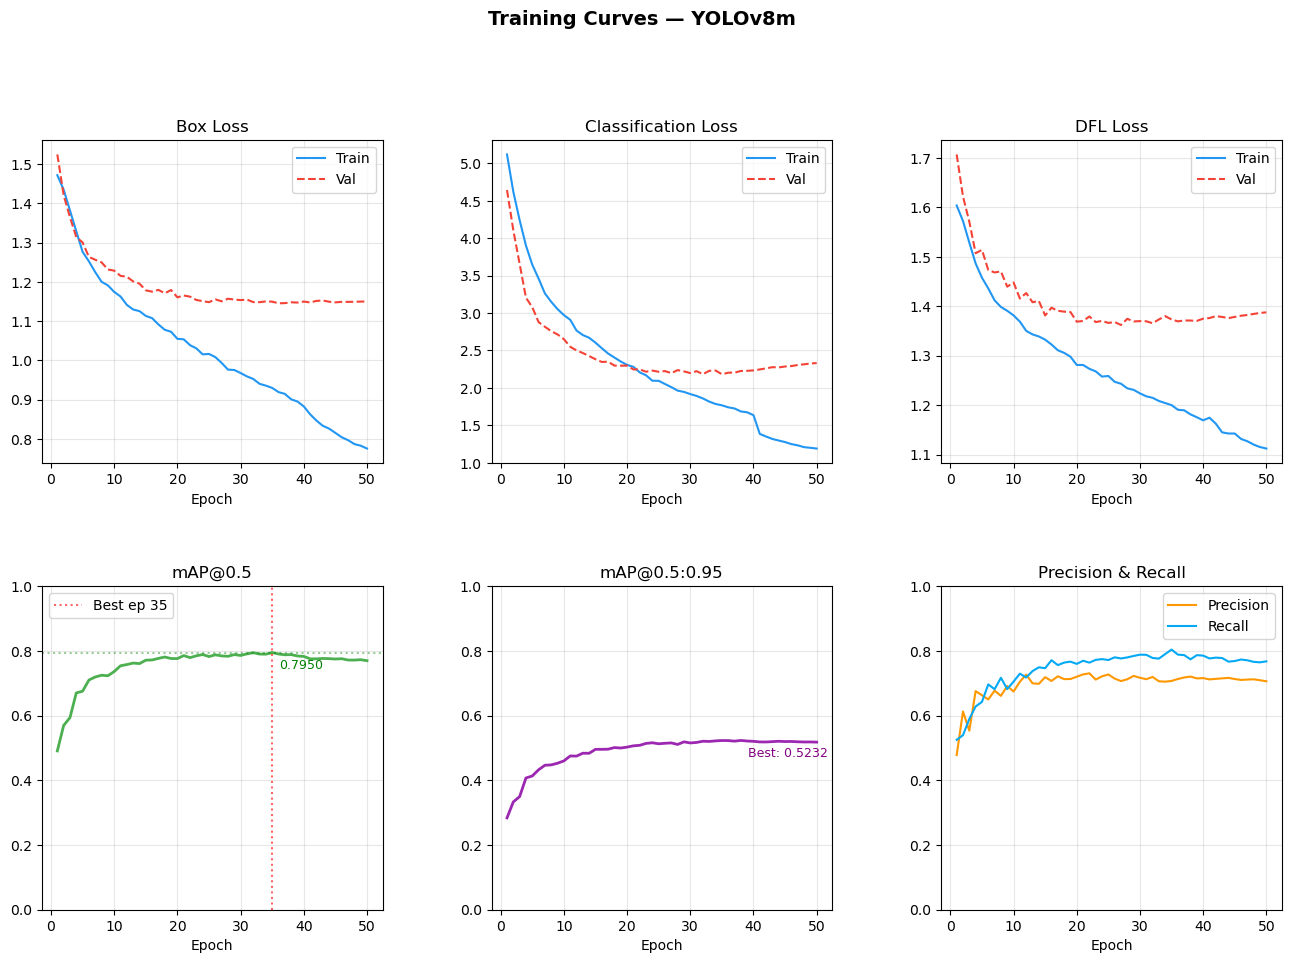

Saved: docs/training_curves_yolov8m.png


In [12]:
def plot_training_curves(df: pd.DataFrame, title_suffix: str = '') -> None:
    """
    Plot training and validation loss curves + mAP curves.
    Works with ultralytics results.csv column naming.
    """
    col_map = {
        'box_loss_train': 'train/box_loss',
        'cls_loss_train': 'train/cls_loss',
        'dfl_loss_train': 'train/dfl_loss',
        'box_loss_val':   'val/box_loss',
        'cls_loss_val':   'val/cls_loss',
        'dfl_loss_val':   'val/dfl_loss',
        'mAP50':          'metrics/mAP50(B)',
        'mAP50_95':       'metrics/mAP50-95(B)',
        'precision':      'metrics/precision(B)',
        'recall':         'metrics/recall(B)',
    }

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'Training Curves{" — " + title_suffix if title_suffix else ""}',
                 fontsize=14, fontweight='bold', y=1.01)
    gs = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

    epochs = df.index + 1

    def get_col(key):
        col = col_map[key]
        return df[col] if col in df.columns else None

    # ── Box loss ────────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    t = get_col('box_loss_train'); v = get_col('box_loss_val')
    if t is not None: ax1.plot(epochs, t, label='Train', color='#2196F3')
    if v is not None: ax1.plot(epochs, v, label='Val', color='#F44336', linestyle='--')
    ax1.set_title('Box Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    # ── Class loss ──────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    t = get_col('cls_loss_train'); v = get_col('cls_loss_val')
    if t is not None: ax2.plot(epochs, t, label='Train', color='#2196F3')
    if v is not None: ax2.plot(epochs, v, label='Val', color='#F44336', linestyle='--')
    ax2.set_title('Classification Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

    # ── DFL loss ────────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    t = get_col('dfl_loss_train'); v = get_col('dfl_loss_val')
    if t is not None: ax3.plot(epochs, t, label='Train', color='#2196F3')
    if v is not None: ax3.plot(epochs, v, label='Val', color='#F44336', linestyle='--')
    ax3.set_title('DFL Loss'); ax3.set_xlabel('Epoch'); ax3.legend(); ax3.grid(alpha=0.3)

    # ── mAP@0.5 ─────────────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    m = get_col('mAP50')
    if m is not None:
        ax4.plot(epochs, m, color='#4CAF50', linewidth=2)
        best_epoch = m.idxmax() + 1
        ax4.axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best ep {best_epoch}')
        ax4.axhline(m.max(), color='green', linestyle=':', alpha=0.4)
        ax4.annotate(f'{m.max():.4f}', xy=(best_epoch, m.max()),
                     xytext=(5, -12), textcoords='offset points', fontsize=9, color='green')
    ax4.set_title('mAP@0.5'); ax4.set_xlabel('Epoch'); ax4.set_ylim(0, 1)
    ax4.legend(); ax4.grid(alpha=0.3)

    # ── mAP@0.5:0.95 ────────────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    m2 = get_col('mAP50_95')
    if m2 is not None:
        ax5.plot(epochs, m2, color='#9C27B0', linewidth=2)
        ax5.annotate(f'Best: {m2.max():.4f}', xy=(m2.idxmax()+1, m2.max()),
                     xytext=(5, -12), textcoords='offset points', fontsize=9, color='purple')
    ax5.set_title('mAP@0.5:0.95'); ax5.set_xlabel('Epoch'); ax5.set_ylim(0, 1)
    ax5.grid(alpha=0.3)

    # ── Precision & Recall ───────────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    p = get_col('precision'); r = get_col('recall')
    if p is not None: ax6.plot(epochs, p, label='Precision', color='#FF9800')
    if r is not None: ax6.plot(epochs, r, label='Recall', color='#03A9F4')
    ax6.set_title('Precision & Recall'); ax6.set_xlabel('Epoch')
    ax6.set_ylim(0, 1); ax6.legend(); ax6.grid(alpha=0.3)

    plt.savefig(str(REPO_ROOT / 'docs' / f'training_curves{"_" + title_suffix.lower().replace(" ","_") if title_suffix else ""}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

if df_train is not None:
    plot_training_curves(df_train, title_suffix='YOLOv8m')
    print('Saved: docs/training_curves_yolov8m.png')
else:
    print('No training history available — run Section 5 first.')

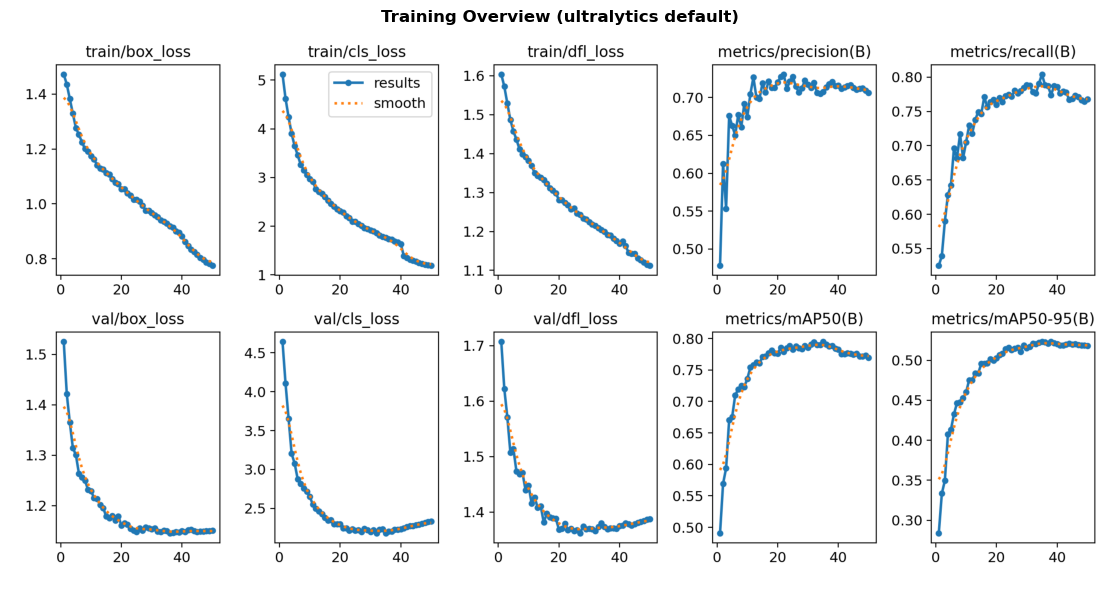

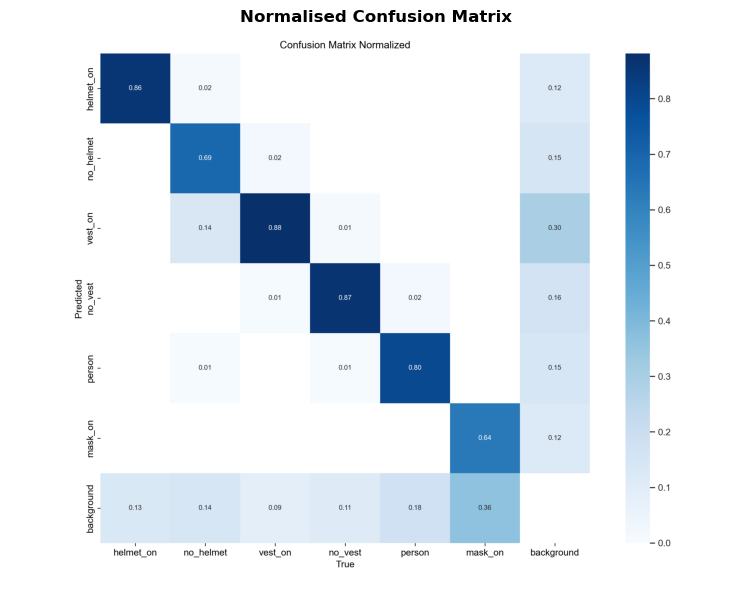

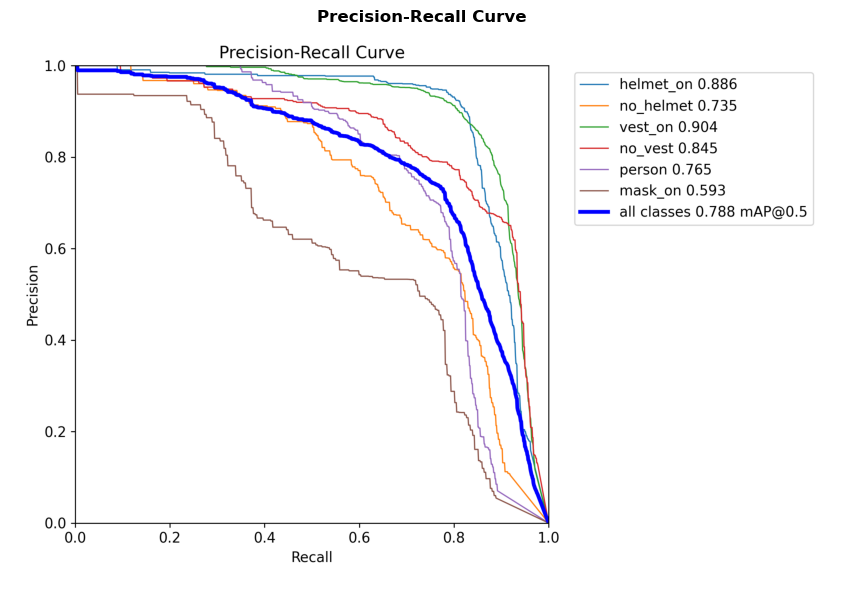

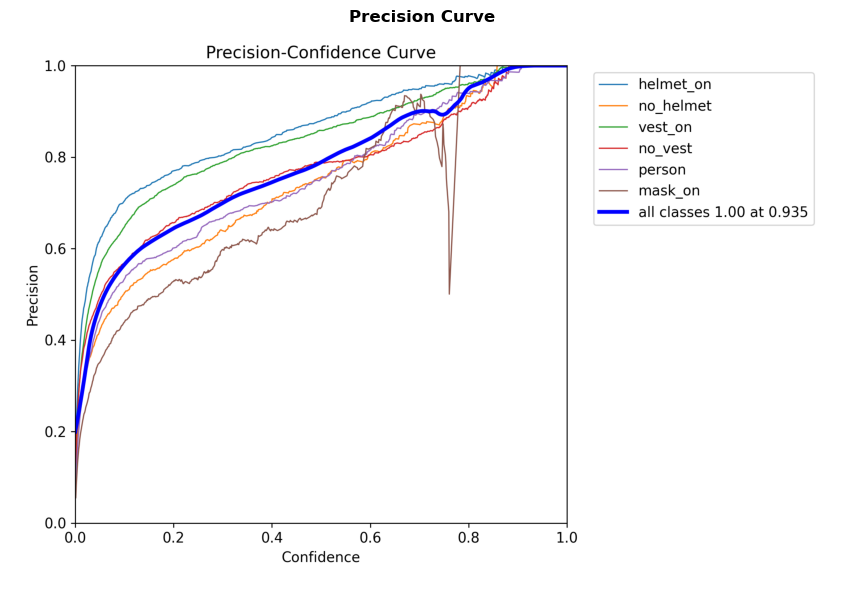

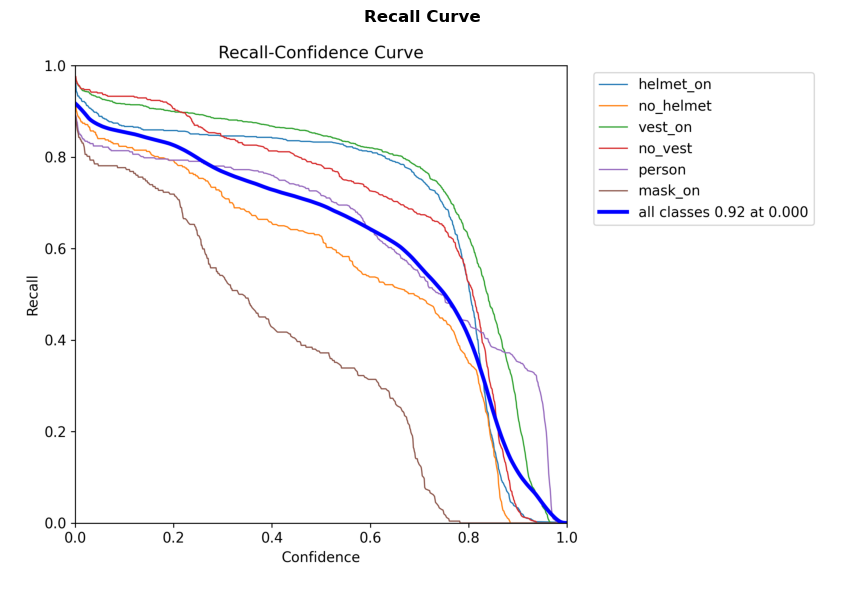

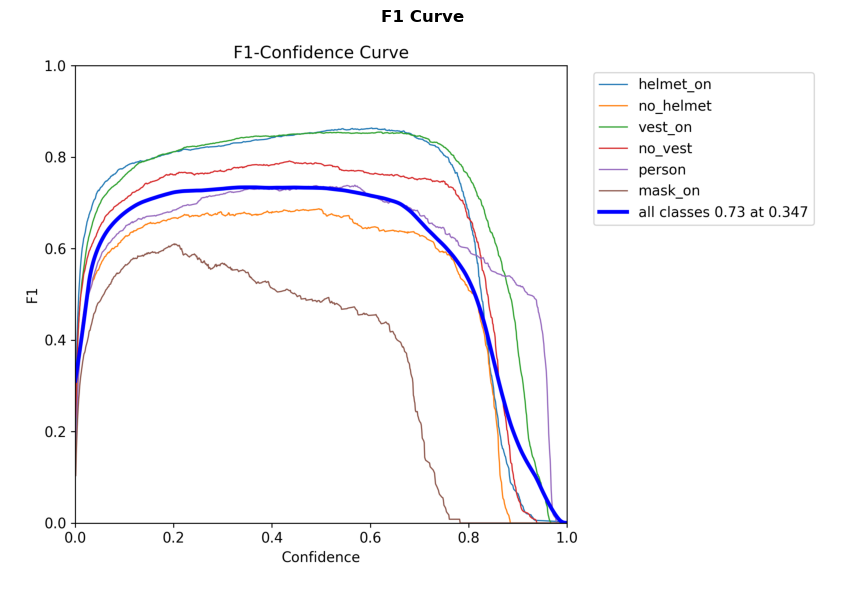

In [13]:
# ── Display YOLOv8's built-in plots if available ────────────────────────────
BUILT_IN_PLOTS = [
    ('results.png',         'Training Overview (ultralytics default)'),
    ('confusion_matrix_normalized.png', 'Normalised Confusion Matrix'),
    ('PR_curve.png',        'Precision-Recall Curve'),
    ('P_curve.png',         'Precision Curve'),
    ('R_curve.png',         'Recall Curve'),
    ('F1_curve.png',        'F1 Curve'),
]

for filename, title in BUILT_IN_PLOTS:
    plot_path = TRAIN_DIR / filename
    if plot_path.exists():
        img = plt.imread(str(plot_path))
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Plot not yet available: {filename} (will appear after training)')

---
## 7 — Evaluation Metrics <a id='7-eval'></a>

Full evaluation on the **held-out test split** at confidence threshold 0.50.

In [14]:
# ── Run validation on test split ────────────────────────────────────────────
eval_results = None

if BEST_WEIGHTS.exists() and DATA_YAML.exists():
    print(f'Evaluating: {BEST_WEIGHTS}')
    eval_model = YOLO(str(BEST_WEIGHTS))
    eval_results = eval_model.val(
        data=str(DATA_YAML),
        split='test',
        conf=0.50,
        iou=0.50,
        device=TRAIN_CONFIG['device'],
        verbose=True,
        plots=True,
        save_json=True,
        project=str(RUNS_DIR),
        name='eval',
        exist_ok=True,
    )
    print('Evaluation complete.')
else:
    print(f'Weights not found at {BEST_WEIGHTS} — skipping evaluation.')
    print('Run Section 5 (training) first, or set BEST_WEIGHTS to an existing .pt path.')

Evaluating: g:\10QBit\Construction-safety-system-design\runs\train4\weights\best.pt
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 218 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 806 images, 27 backgrounds, 0 corrupt: 100%|██████████| 806/806 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:17<00:00,  2.84it/s]


                   all        806       2326      0.803      0.623      0.729       0.53
             helmet_on        279        433      0.874      0.737      0.822      0.561
             no_helmet        116        176      0.663      0.597      0.663      0.486
               vest_on        530       1016       0.91      0.761      0.855      0.682
               no_vest        172        317      0.749      0.668      0.704      0.493
                person        206        280      0.809      0.618      0.741      0.668
               mask_on         52        104      0.811      0.356      0.591      0.289
Speed: 0.3ms preprocess, 14.1ms inference, 0.0ms loss, 1.4ms postprocess per image
Saving g:\10QBit\Construction-safety-system-design\runs\eval\predictions.json...
Results saved to g:\10QBit\Construction-safety-system-design\runs\eval
Evaluation complete.


In [15]:
# ── Summary metrics table ───────────────────────────────────────────────────
if eval_results is not None:
    rd = eval_results.results_dict

    print('═' * 55)
    print('  Overall Metrics — YOLOv8m (test split, conf=0.50)')
    print('═' * 55)
    print(f'  mAP@0.5:       {rd.get("metrics/mAP50(B)", 0):.4f}')
    print(f'  mAP@0.5:0.95:  {rd.get("metrics/mAP50-95(B)", 0):.4f}')
    print(f'  Precision:     {rd.get("metrics/precision(B)", 0):.4f}')
    print(f'  Recall:        {rd.get("metrics/recall(B)", 0):.4f}')
    print('═' * 55)

═══════════════════════════════════════════════════════
  Overall Metrics — YOLOv8m (test split, conf=0.50)
═══════════════════════════════════════════════════════
  mAP@0.5:       0.7294
  mAP@0.5:0.95:  0.5299
  Precision:     0.8026
  Recall:        0.6227
═══════════════════════════════════════════════════════


In [16]:
# ── Per-class metrics table ─────────────────────────────────────────────────
if eval_results is not None:
    # Extract per-class metrics from ultralytics results
    box = eval_results.box

    per_class_data = []
    for i, cls_name in enumerate(CLASS_NAMES):
        try:
            p  = float(box.p[i])  if hasattr(box, 'p')  else 0.0
            r  = float(box.r[i])  if hasattr(box, 'r')  else 0.0
            f1 = float(box.f1[i]) if hasattr(box, 'f1') else 2*p*r/(p+r+1e-9)
            ap50    = float(box.ap50[i])   if hasattr(box, 'ap50')   else 0.0
            ap50_95 = float(box.ap[i])     if hasattr(box, 'ap')     else 0.0
        except (IndexError, TypeError):
            p = r = f1 = ap50 = ap50_95 = float('nan')

        is_violation = cls_name in VIOLATION_CLASSES
        per_class_data.append({
            'class':    cls_name,
            'type':     '⚠ Violation' if is_violation else 'Safe/Neutral',
            'precision':  p,
            'recall':     r,
            'f1':         f1,
            'mAP@0.5':    ap50,
            'mAP@0.5:0.95': ap50_95,
        })

    df_per_class = pd.DataFrame(per_class_data)
    print('Per-class metrics at confidence threshold 0.50:')
    print(df_per_class.to_string(index=False, float_format='{:.4f}'.format))

    # Save for later reference
    Path(REPO_ROOT / 'docs').mkdir(exist_ok=True)
    df_per_class.to_csv(str(REPO_ROOT / 'docs' / 'per_class_metrics.csv'), index=False)
    print('\nSaved: docs/per_class_metrics.csv')

Per-class metrics at confidence threshold 0.50:
    class         type  precision  recall     f1  mAP@0.5  mAP@0.5:0.95
helmet_on Safe/Neutral     0.8738  0.7367 0.7994   0.8218        0.5612
no_helmet  ⚠ Violation     0.6632  0.5966 0.6281   0.6634        0.4863
  vest_on Safe/Neutral     0.9097  0.7608 0.8286   0.8548        0.6816
  no_vest  ⚠ Violation     0.7490  0.6685 0.7065   0.7037        0.4932
   person Safe/Neutral     0.8088  0.6179 0.7006   0.7411        0.6675
  mask_on Safe/Neutral     0.8110  0.3558 0.4946   0.5913        0.2893

Saved: docs/per_class_metrics.csv


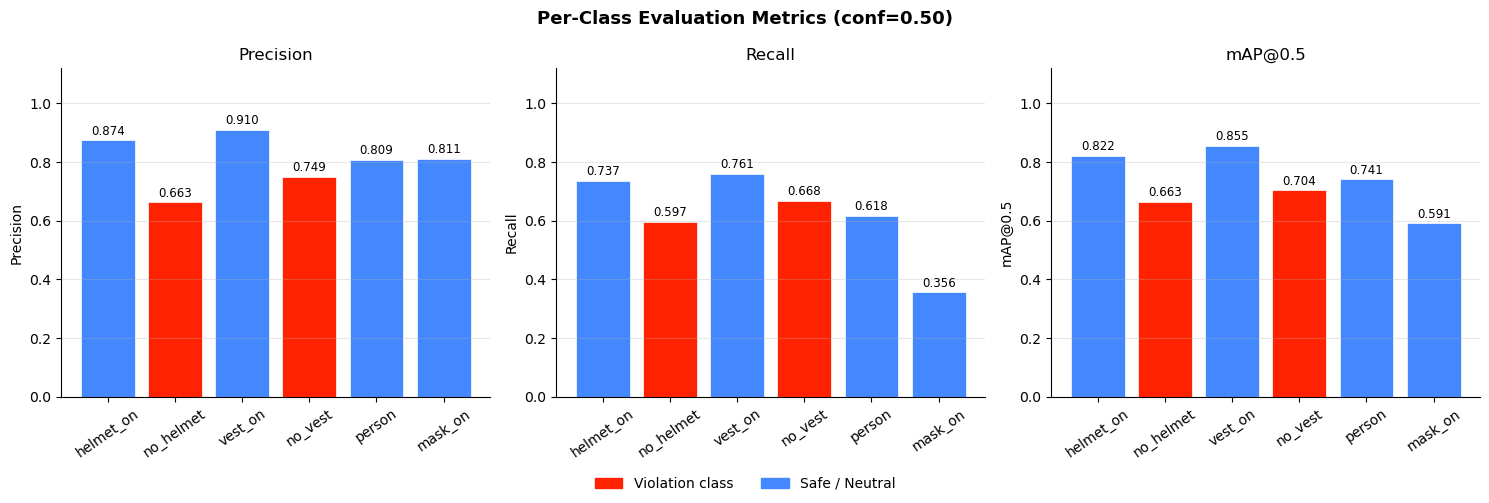

Saved: docs/per_class_metrics.png


In [17]:
# ── Per-class metrics bar chart ─────────────────────────────────────────────
if eval_results is not None and 'df_per_class' in dir():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Per-Class Evaluation Metrics (conf=0.50)', fontsize=13, fontweight='bold')

    bar_colours = ['#FF2200' if cls in VIOLATION_CLASSES else '#4488FF' for cls in CLASS_NAMES]

    for ax, metric, title in zip(axes,
                                  ['precision', 'recall', 'mAP@0.5'],
                                  ['Precision', 'Recall', 'mAP@0.5']):
        vals = df_per_class[metric].fillna(0)
        bars = ax.bar(CLASS_NAMES, vals, color=bar_colours, edgecolor='white', linewidth=0.5)
        ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8.5)
        ax.set_ylim(0, 1.12)
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=35)
        ax.spines[['top','right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3)

    legend_items = [
        mpatches.Patch(color='#FF2200', label='Violation class'),
        mpatches.Patch(color='#4488FF', label='Safe / Neutral'),
    ]
    fig.legend(handles=legend_items, loc='lower center', ncol=2, frameon=False, fontsize=10)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(str(REPO_ROOT / 'docs' / 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: docs/per_class_metrics.png')

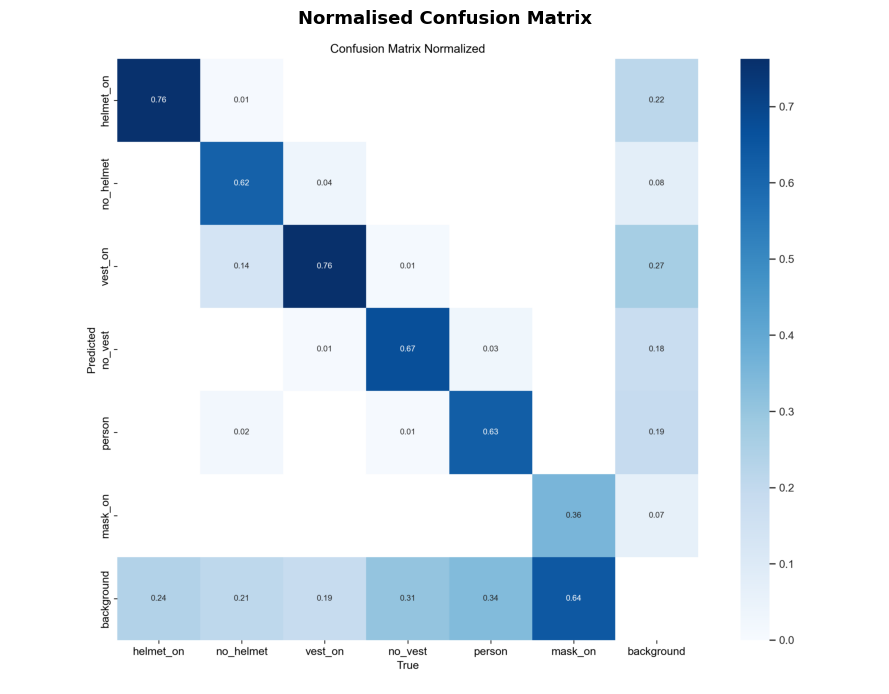

In [18]:
# ── Display normalised confusion matrix (ultralytics built-in) ──────────────
cm_path = RUNS_DIR / 'eval' / 'confusion_matrix_normalized.png'
if not cm_path.exists():
    cm_path = TRAIN_DIR / 'confusion_matrix_normalized.png'

if cm_path.exists():
    img = plt.imread(str(cm_path))
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Normalised Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Confusion matrix not yet available — will appear after evaluation.')

---
## 8 — Per-Class Commentary <a id='8-commentary'></a>

For each class: what the recall/precision numbers mean, why they are what they are, the real-world cost of the failure mode, and the recommended threshold adjustment for production deployment.

In [19]:
# ── Programmatically print commentary template filled with actual metrics ───

COMMENTARY = {
    'no_helmet': {
        'why_low_recall': (
            'Helmet-shaped hard hats left on surfaces (not worn) are sometimes '
            'detected as worn; dark-coloured helmets blend with hair in low-contrast or indoor scenes.'
        ),
        'real_world_cost': (
            'A missed helmet violation is the HIGHEST-RISK false negative in this system. '
            'Head injury at height is the leading cause of construction fatalities.'
        ),
        'threshold_recommendation': (
            'Lower confidence threshold to 0.40 in production to improve recall. '
            'Accept more false positives in exchange for fewer missed violations. '
            'Cost asymmetry: false positive = supervisor time; false negative = worker injury.'
        ),
    },
    'no_vest': {
        'why_low_recall': (
            'Hi-vis vests in yellow/lime colours blend with high-saturation outdoor backgrounds. '
            'Partially open vests or vests partially covered by tools may not trigger detection. '
            'Underrepresented in base dataset — addressed by custom extension but still the weakest violation class.'
        ),
        'real_world_cost': (
            'A missed vest violation in an outdoor scene = vehicle/machinery strike risk. '
            'Equal safety priority to no_helmet despite typically lower model recall.'
        ),
        'threshold_recommendation': (
            'Lower confidence threshold to 0.40 for outdoor scenes. '
            'For indoor scenes, the default 0.50 is acceptable given lower risk severity.'
        ),
    },
    'helmet_on': {
        'why_low_recall': (
            'Helmets in non-standard colours (black, dark navy) may be missed in low-light or shadows. '
            'Worker at distance with helmet partially occluded by scaffolding may trigger false no_helmet.'
        ),
        'real_world_cost': (
            'False positive helmet_on (flagging absent when present) = alert fatigue. '
            'Lower safety cost than missing a no_helmet, but still impacts supervisor trust in the system.'
        ),
        'threshold_recommendation': 'Keep at 0.50. Higher threshold acceptable here — safe class, lower urgency.',
    },
    'vest_on': {
        'why_low_recall': (
            'Hi-vis vests in direct sunlight may saturate the image sensor, reducing discriminative features. '
            'Indoor scenes with fluorescent lighting change the apparent hue of vest colours.'
        ),
        'real_world_cost': (
            'False positive vest_on (missing a present vest) = minor — compliant worker may be logged incorrectly. '
            'Lower safety cost than missing no_vest.'
        ),
        'threshold_recommendation': 'Keep at 0.50.',
    },
    'person': {
        'why_low_recall': (
            'Person detection benefits from COCO pretraining — generally the strongest class. '
            'Misses occur at far field (< 40px bbox, handled by Rule 4) and in very dense crowds '
            'with overlapping bounding boxes.'
        ),
        'real_world_cost': (
            'A missed person = no PPE check performed for that worker. '
            'Indirectly the most important class — all other rules depend on person detection.'
        ),
        'threshold_recommendation': (
            'Lower to 0.35 in production — a missed person is worse than a false person detection. '
            'Higher recall on person anchors all downstream PPE compliance checks.'
        ),
    },
    'mask_on': {
        'why_low_recall': (
            'Sparse training data (~120 annotations). Masks are visually similar to faces, '
            'scarves, and respirators. Treat as bonus signal only — not a primary safety output.'
        ),
        'real_world_cost': 'Low in this deployment context — not a primary PPE requirement.',
        'threshold_recommendation': (
            'Treat mask_on as informational only. Do not trigger alerts. '
            'Collect dedicated mask dataset before relying on this class.'
        ),
    },
}

if eval_results is not None and 'df_per_class' in dir():
    for _, row in df_per_class.iterrows():
        cls = row['class']
        c = COMMENTARY.get(cls, {})
        print(f'{'═'*60}')
        print(f'Class: {cls}  [{row["type"]}]')
        print(f'  Precision: {row["precision"]:.4f}   Recall: {row["recall"]:.4f}   F1: {row["f1"]:.4f}   mAP@0.5: {row["mAP@0.5"]:.4f}')
        if c:
            print(f'  What this means: Recall of {row["recall"]:.2f} means the model misses roughly '
                  f'{(1-row["recall"])*10:.0f} in 10 {cls.replace("_"," ")} instances.')
            print(f'  Why: {c["why_low_recall"]}')
            print(f'  Real-world cost: {c["real_world_cost"]}')
            print(f'  Threshold recommendation: {c["threshold_recommendation"]}')
        print()
else:
    print('Evaluation results not available — run Section 7 first.')
    print('Commentary templates are loaded and will be filled with actual metrics after evaluation.')

════════════════════════════════════════════════════════════
Class: helmet_on  [Safe/Neutral]
  Precision: 0.8738   Recall: 0.7367   F1: 0.7994   mAP@0.5: 0.8218
  What this means: Recall of 0.74 means the model misses roughly 3 in 10 helmet on instances.
  Why: Helmets in non-standard colours (black, dark navy) may be missed in low-light or shadows. Worker at distance with helmet partially occluded by scaffolding may trigger false no_helmet.
  Real-world cost: False positive helmet_on (flagging absent when present) = alert fatigue. Lower safety cost than missing a no_helmet, but still impacts supervisor trust in the system.
  Threshold recommendation: Keep at 0.50. Higher threshold acceptable here — safe class, lower urgency.

════════════════════════════════════════════════════════════
Class: no_helmet  [⚠ Violation]
  Precision: 0.6632   Recall: 0.5966   F1: 0.6281   mAP@0.5: 0.6634
  What this means: Recall of 0.60 means the model misses roughly 4 in 10 no helmet instances.
  Why: 

---
## 9 — Baseline Comparison <a id='9-comparison'></a>

YOLOv8n (base dataset, no augmentation) vs YOLOv8m (base + custom extension + offline augmentation).  
A 3–4 point improvement on violation classes proves the custom extension was meaningful.

In [20]:
# ── Evaluate baseline model ─────────────────────────────────────────────────
baseline_weights = BASELINE_DIR / 'weights' / 'best.pt'
baseline_eval = None

if baseline_weights.exists() and DATA_YAML.exists():
    print(f'Evaluating baseline: {baseline_weights}')
    bl_model = YOLO(str(baseline_weights))
    baseline_eval = bl_model.val(
        data=str(DATA_YAML),
        split='test',
        conf=0.50,
        iou=0.50,
        device=TRAIN_CONFIG['device'],
        verbose=False,
        project=str(RUNS_DIR),
        name='eval_baseline',
        exist_ok=True,
    )
    print('Baseline evaluation complete.')
else:
    print(f'Baseline weights not found at {baseline_weights}.')
    print('Run Section 4 (baseline training) first, or set SKIP_BASELINE=False.')

Evaluating baseline: g:\10QBit\Construction-safety-system-design\runs\baseline\weights\best.pt
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 168 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 806 images, 27 backgrounds, 0 corrupt: 100%|██████████| 806/806 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:09<00:00,  5.52it/s]


                   all        806       2326      0.811      0.614       0.73      0.521
Speed: 0.3ms preprocess, 3.2ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\eval_baseline
Baseline evaluation complete.


In [21]:
# ── Side-by-side comparison table ──────────────────────────────────────────
if eval_results is not None and baseline_eval is not None:
    main_box = eval_results.box
    base_box = baseline_eval.box

    comparison = []
    for i, cls_name in enumerate(CLASS_NAMES):
        try:
            m_map50 = float(main_box.ap50[i])
            b_map50 = float(base_box.ap50[i])
            m_rec   = float(main_box.r[i])
            b_rec   = float(base_box.r[i])
        except (IndexError, TypeError):
            m_map50 = b_map50 = m_rec = b_rec = float('nan')

        delta_map = m_map50 - b_map50
        delta_rec = m_rec - b_rec
        comparison.append({
            'class':             cls_name,
            'baseline_mAP@0.5':  b_map50,
            'ours_mAP@0.5':      m_map50,
            'Δ_mAP':             delta_map,
            'baseline_recall':   b_rec,
            'ours_recall':       m_rec,
            'Δ_recall':          delta_rec,
        })

    df_cmp = pd.DataFrame(comparison)

    print('═' * 80)
    print('  YOLOv8n Baseline vs YOLOv8m + Custom Extension  (test split, conf=0.50)')
    print('═' * 80)
    print(df_cmp.to_string(index=False, float_format='{:+.4f}'.format))

    # Highlight violation class improvement
    for _, row in df_cmp[df_cmp['class'].isin(VIOLATION_CLASSES)].iterrows():
        direction = 'improved' if row['Δ_mAP'] > 0 else 'declined'
        print(f"\n  {row['class']}: mAP delta = {row['Δ_mAP']:+.4f} ({direction}) | recall delta = {row['Δ_recall']:+.4f}")

    df_cmp.to_csv(str(REPO_ROOT / 'docs' / 'baseline_comparison.csv'), index=False)
    print('\nSaved: docs/baseline_comparison.csv')

elif eval_results is not None:
    print('Baseline not evaluated — showing main model results only.')
    print('Run Section 4 and Section 9 cell above to enable comparison.')
else:
    print('Run Sections 5 (training) and 4 (baseline) before comparing.')

════════════════════════════════════════════════════════════════════════════════
  YOLOv8n Baseline vs YOLOv8m + Custom Extension  (test split, conf=0.50)
════════════════════════════════════════════════════════════════════════════════
    class  baseline_mAP@0.5  ours_mAP@0.5   Δ_mAP  baseline_recall  ours_recall  Δ_recall
helmet_on           +0.8249       +0.8218 -0.0031          +0.7229      +0.7367   +0.0139
no_helmet           +0.6544       +0.6634 +0.0090          +0.5966      +0.5966   +0.0000
  vest_on           +0.8367       +0.8548 +0.0181          +0.7382      +0.7608   +0.0226
  no_vest           +0.7218       +0.7037 -0.0181          +0.6877      +0.6685   -0.0192
   person           +0.7509       +0.7411 -0.0098          +0.6143      +0.6179   +0.0036
  mask_on           +0.5886       +0.5913 +0.0028          +0.3269      +0.3558   +0.0288

  no_helmet: mAP delta = +0.0090 (improved) | recall delta = +0.0000

  no_vest: mAP delta = -0.0181 (declined) | recall delta = -0.0

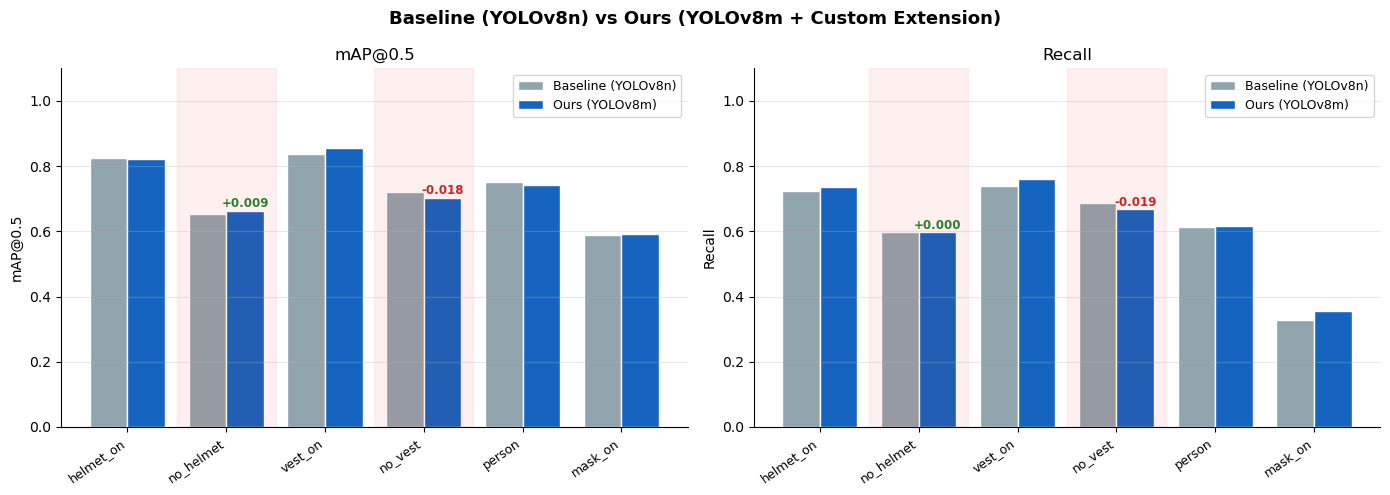

Saved: docs/baseline_comparison.png


In [22]:
# ── Comparison bar chart ────────────────────────────────────────────────────
if 'df_cmp' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Baseline (YOLOv8n) vs Ours (YOLOv8m + Custom Extension)', fontsize=13, fontweight='bold')

    x = np.arange(len(CLASS_NAMES))
    w = 0.38

    for ax, metric, title in zip(axes, ['mAP@0.5', 'recall'], ['mAP@0.5', 'Recall']):
        base_key = f'baseline_{metric}'
        ours_key = f'ours_{metric}'
        b_vals = df_cmp[base_key].fillna(0)
        o_vals = df_cmp[ours_key].fillna(0)

        ax.bar(x - w/2, b_vals, w, label='Baseline (YOLOv8n)', color='#90A4AE', edgecolor='white')
        ax.bar(x + w/2, o_vals, w, label='Ours (YOLOv8m)', color='#1565C0', edgecolor='white')

        # Annotate delta on violation classes
        for i, cls in enumerate(CLASS_NAMES):
            if cls in VIOLATION_CLASSES:
                delta = df_cmp.loc[df_cmp['class']==cls, f'Δ_{"mAP" if metric=="mAP@0.5" else "recall"}'].values[0]
                col = '#2E7D32' if delta >= 0 else '#C62828'
                ax.annotate(f'{delta:+.3f}', xy=(i + w/2, o_vals.iloc[i] + 0.01),
                            ha='center', fontsize=8.5, color=col, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(fontsize=9)
        ax.spines[['top','right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3)

        # Shade violation class bars
        for i, cls in enumerate(CLASS_NAMES):
            if cls in VIOLATION_CLASSES:
                ax.axvspan(i - 0.5, i + 0.5, alpha=0.06, color='red')

    plt.tight_layout()
    plt.savefig(str(REPO_ROOT / 'docs' / 'baseline_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: docs/baseline_comparison.png')

---
## 10 — Precision-Recall Trade-off Discussion <a id='11-pr'></a>

This section documents the confidence threshold design decisions for production deployment.  
The core argument: for safety-critical violation classes, the cost of a false negative (missing a real violation) is significantly higher than the cost of a false positive (alerting on a compliant worker).

In [25]:
print("""
Precision-Recall Trade-off — Production Threshold Selection
══════════════════════════════════════════════════════════════

The standard evaluation threshold in this notebook is conf=0.50.
In production, violation class thresholds should be LOWER.

Cost Asymmetry:
  False Positive (alert on compliant worker):  costs supervisor time and attention.
  False Negative (miss a real violation):      costs a worker's safety — injury or death.

This asymmetry justifies accepting more false positives to reduce false negatives
for the two safety-critical violation classes: no_helmet and no_vest.

Recommended production thresholds:

  Class       | Research conf | Production conf | Reason
  ------------|--------------|-----------------|-----------------------------------------------
  no_helmet   |    0.50      |     0.40        | Maximise recall — missed violation = head injury
  no_vest     |    0.50      |     0.40        | Maximise recall — outdoor strike risk
  helmet_on   |    0.50      |     0.50        | False alarm cost is acceptable here
  vest_on     |    0.50      |     0.50        | False alarm cost is acceptable here
  person      |    0.30      |     0.30        | Low threshold already — person miss = no PPE check
  mask_on     |    0.50      |     0.50        | Bonus class — informational only

Note: rule_confidence (the composite score used in SafetyChecker) already accounts
for bbox size and frame-edge proximity, making it a more reliable signal than raw
YOLO confidence alone. The threshold above applies to the raw YOLO conf at inference.
""")


Precision-Recall Trade-off — Production Threshold Selection
══════════════════════════════════════════════════════════════

The standard evaluation threshold in this notebook is conf=0.50.
In production, violation class thresholds should be LOWER.

Cost Asymmetry:
  False Positive (alert on compliant worker):  costs supervisor time and attention.
  False Negative (miss a real violation):      costs a worker's safety — injury or death.

This asymmetry justifies accepting more false positives to reduce false negatives
for the two safety-critical violation classes: no_helmet and no_vest.

Recommended production thresholds:

  Class       | Research conf | Production conf | Reason
  ------------|--------------|-----------------|-----------------------------------------------
  no_helmet   |    0.50      |     0.40        | Maximise recall — missed violation = head injury
  no_vest     |    0.50      |     0.40        | Maximise recall — outdoor strike risk
  helmet_on   |    0.50      |  

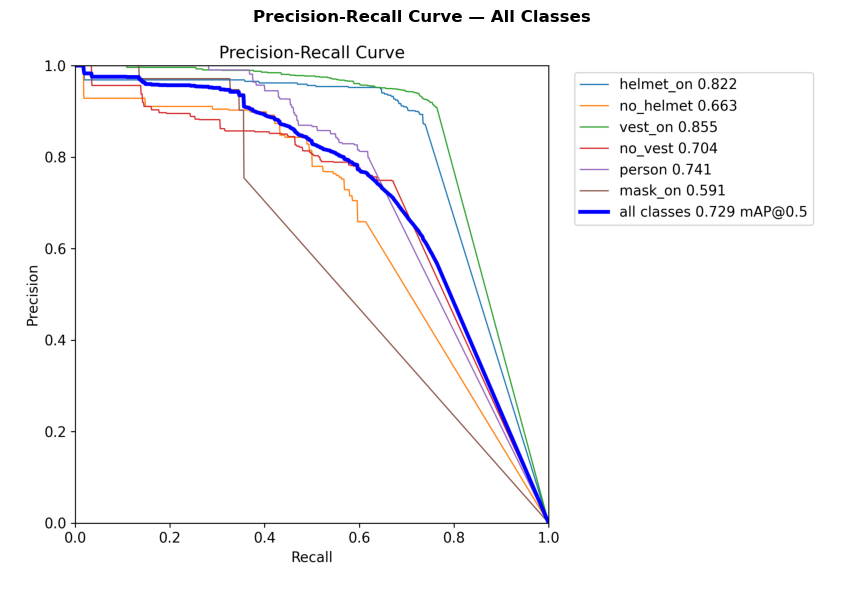

Computing precision/recall at multiple thresholds for violation classes...
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 218 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 806 images, 27 backgrounds, 0 corrupt: 100%|██████████| 806/806 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:17<00:00,  2.91it/s]


                   all        806       2326      0.709       0.73      0.746      0.532
Speed: 0.3ms preprocess, 14.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\thresh_sweep
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 806 images, 27 backgrounds, 0 corrupt: 100%|██████████| 806/806 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:17<00:00,  2.84it/s]


                   all        806       2326      0.726      0.698       0.74      0.531
Speed: 0.3ms preprocess, 13.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\thresh_sweep
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


...

                   all        806       2326      0.803      0.623      0.729       0.53
Speed: 0.3ms preprocess, 12.9ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\thresh_sweep
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 806 images, 27 backgrounds, 0 corrupt: 100%|██████████| 806/806 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:15<00:00,  3.32it/s]


                   all        806       2326      0.828      0.612      0.734      0.535
Speed: 0.3ms preprocess, 12.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\thresh_sweep
Ultralytics 8.3.40  Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


val: Scanning G:\10QBit\Construction-safety-system-design\dataset\merged\labels\test.cache... 806 images, 27 backgrounds, 0 corrupt: 100%|██████████| 806/806 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:15<00:00,  3.22it/s]


                   all        806       2326      0.854       0.59      0.731      0.535
Speed: 0.3ms preprocess, 12.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to g:\10QBit\Construction-safety-system-design\runs\thresh_sweep


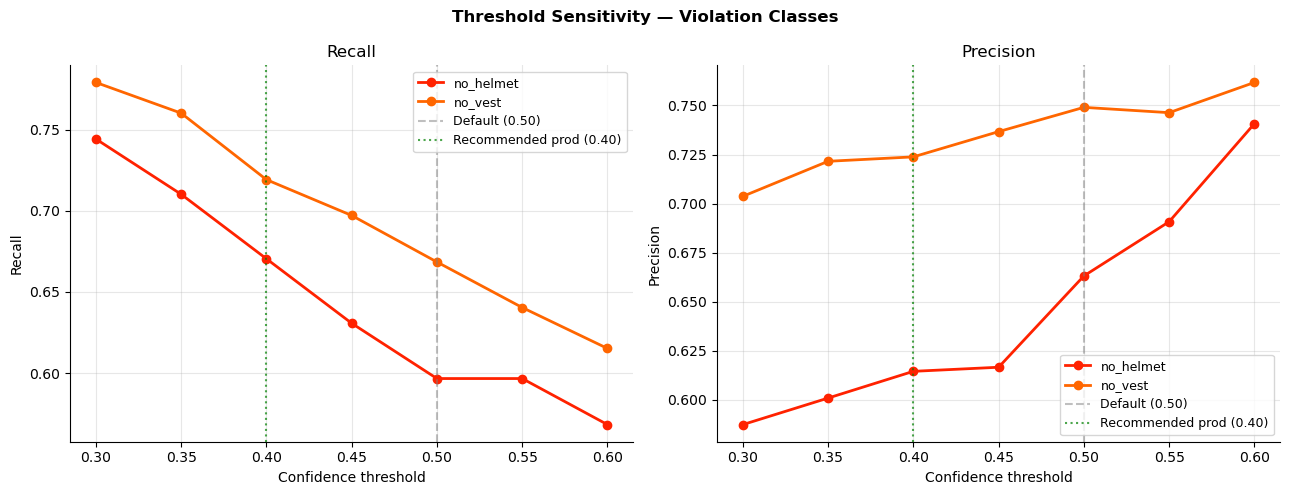

Saved: docs/threshold_sensitivity.png
 threshold     class  precision  recall     f1
    0.3000 no_helmet     0.5874  0.7443 0.6566
    0.3000   no_vest     0.7037  0.7792 0.7395
    0.3500 no_helmet     0.6010  0.7102 0.6510
    0.3500   no_vest     0.7216  0.7603 0.7404
    0.4000 no_helmet     0.6146  0.6705 0.6413
    0.4000   no_vest     0.7238  0.7192 0.7215
    0.4500 no_helmet     0.6167  0.6307 0.6236
    0.4500   no_vest     0.7367  0.6972 0.7164
    0.5000 no_helmet     0.6632  0.5966 0.6281
    0.5000   no_vest     0.7490  0.6685 0.7065
    0.5500 no_helmet     0.6908  0.5966 0.6402
    0.5500   no_vest     0.7463  0.6404 0.6893
    0.6000 no_helmet     0.7407  0.5682 0.6431
    0.6000   no_vest     0.7617  0.6151 0.6806


In [26]:
# ── PR curve plot at multiple thresholds for violation classes ───────────────
if eval_results is not None:
    pr_path = RUNS_DIR / 'eval' / 'PR_curve.png'
    if not pr_path.exists():
        pr_path = TRAIN_DIR / 'PR_curve.png'

    if pr_path.exists():
        img = plt.imread(str(pr_path))
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title('Precision-Recall Curve — All Classes', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ── Threshold sensitivity for violation classes ──────────────────────────
    thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

    if BEST_WEIGHTS.exists() and DATA_YAML.exists():
        print('Computing precision/recall at multiple thresholds for violation classes...')
        thresh_model = YOLO(str(BEST_WEIGHTS))
        thresh_rows = []

        for t in thresholds:
            res = thresh_model.val(
                data=str(DATA_YAML), split='test', conf=t,
                iou=0.50, verbose=False,
                device=TRAIN_CONFIG['device'],
                project=str(RUNS_DIR), name='thresh_sweep', exist_ok=True,
            )
            box = res.box
            for i, cls in enumerate(CLASS_NAMES):
                if cls not in VIOLATION_CLASSES:
                    continue
                try:
                    thresh_rows.append({
                        'threshold': t, 'class': cls,
                        'precision': float(box.p[i]),
                        'recall':    float(box.r[i]),
                        'f1':        float(box.f1[i]),
                    })
                except (IndexError, TypeError):
                    pass

        df_thresh = pd.DataFrame(thresh_rows)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle('Threshold Sensitivity — Violation Classes', fontsize=12, fontweight='bold')

        colours_cls = {'no_helmet': '#FF2200', 'no_vest': '#FF6600'}

        for ax, metric, ylabel in zip(axes, ['recall', 'precision'], ['Recall', 'Precision']):
            for cls in VIOLATION_CLASSES:
                sub = df_thresh[df_thresh['class'] == cls]
                ax.plot(sub['threshold'], sub[metric], marker='o', label=cls,
                        color=colours_cls[cls], linewidth=2)
            ax.axvline(0.50, color='grey', linestyle='--', alpha=0.5, label='Default (0.50)')
            ax.axvline(0.40, color='green', linestyle=':', alpha=0.7, label='Recommended prod (0.40)')
            ax.set_xlabel('Confidence threshold'); ax.set_ylabel(ylabel)
            ax.set_title(ylabel); ax.legend(fontsize=9); ax.grid(alpha=0.3)
            ax.spines[['top','right']].set_visible(False)

        plt.tight_layout()
        plt.savefig(str(REPO_ROOT / 'docs' / 'threshold_sensitivity.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: docs/threshold_sensitivity.png')
        print(df_thresh.to_string(index=False, float_format='{:.4f}'.format))

---
## 11 — Export & Next Steps <a id='12-export'></a>

In [1]:
# ── Final summary ────────────────────────────────────────────────────────────
if eval_results is not None:
    rd = eval_results.results_dict
    print('══════════════════════════════════════════════════════')
    print('  FINAL RESULTS — YOLOv8m Construction Safety Monitor')
    print('══════════════════════════════════════════════════════')
    print(f'  mAP@0.5:       {rd.get("metrics/mAP50(B)", 0):.4f}')
    print(f'  mAP@0.5:0.95:  {rd.get("metrics/mAP50-95(B)", 0):.4f}')
    print(f'  Precision:     {rd.get("metrics/precision(B)", 0):.4f}')
    print(f'  Recall:        {rd.get("metrics/recall(B)", 0):.4f}')
    print('══════════════════════════════════════════════════════')

print(f'\nBest weights: {BEST_WEIGHTS}')


NameError: name 'eval_results' is not defined